# STAFF III — download, convert, label, visualize

[STAFF III](https://physionet.org/content/staffiii/1.0.0/) (104 patients, 1000 Hz, ~3.2 GB).  
Long 12-lead ECGs around **prolonged balloon occlusion** of LAD / RCA / LCX / LM, with inflation and deflation times.

Labels are **temporal and anatomical**, not SCP diagnoses: recording phase, occluded artery, D0/D1/D2 timings, `.event` marks.

STAFF III files are large (5–16 MB each). Use the filters below. Already-downloaded `.dat`/`.hea`/`.event` files are not fetched again.

In [8]:
from pathlib import Path
import sys

REPO = Path.cwd() if (Path.cwd() / "evaluation" / "common.py").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO / "evaluation"))

import numpy as np
import pandas as pd
import wfdb
from IPython.display import display

import common as C

# --- subset ---
N_RECORDINGS = 8
PHASES = ["baseline_room", "baseline_cathlab", "inflation"]  # also: post_cathlab, post_room
ARTERIES = ["LAD", "RCA", "LCX"]  # inflation rows only; None = any
REQUIRE_EVENT_FILE = True          # prefer inflations with balloon marks
OVERWRITE_PROCESSED = False
SEED = 42

RAW_DIR, PROC_DIR = C.dataset_dirs("staff_iii")
FALLBACK = [REPO / "data" / "staff_III"]
print("raw:", RAW_DIR)
print("processed:", PROC_DIR)

raw: C:\Users\staso\OneDrive\Pulpit\Nauka\University\Thesis\code\ECG_Delineation\WTdelineator\data\evaluation\raw\staff_iii
processed: C:\Users\staso\OneDrive\Pulpit\Nauka\University\Thesis\code\ECG_Delineation\WTdelineator\data\evaluation\processed\staff_iii


## 1. Official annotation spreadsheet

In [9]:
xlsx = RAW_DIR / "STAFF-III-Database-Annotations.xlsx"
print(
    C.download_single_file(
        "https://physionet.org/files/staffiii/1.0.0/STAFF-III-Database-Annotations.xlsx",
        xlsx,
    )
)

ann = C.parse_staff_annotations(xlsx)
print(ann.groupby(["phase", "occluded_artery"], dropna=False).size().unstack(fill_value=0))
display(ann.head())

skipped
occluded_artery   LAD  LCX  LM  RCA  NaN
phase                                   
baseline_cathlab    0    0   0    0  114
baseline_room       0    0   0    0   73
inflation          58   33   3   58    0
post_cathlab        0    0   0    0   95
post_room           0    0   0    0   96


,patient_id,age,sex,record_id,phase,phase_slot,occluded_artery_raw,occluded_artery,d0_s,d1_s,d2_s,injection_times_s,location_flag
0,1,None,None,001a,baseline_room,BR,None,None,NaN,NaN,NaN,[],None
1,1,None,None,001b,baseline_cathlab,BC1,None,None,NaN,NaN,NaN,[],None
2,1,None,None,001d,post_room,PR1,None,None,NaN,NaN,NaN,[],None
3,1,None,None,001c,inflation,BI1,mid RCA,RCA,60.0,185.0,0.0,[],None
4,2,None,None,002a,baseline_room,BR,None,None,NaN,NaN,NaN,[],None


## 2. Choose a subset, then download

In [10]:
pool = ann.copy()
if PHASES:
    pool = pool[pool["phase"].isin(PHASES)]
if ARTERIES:
    keep_phase = pool["phase"] != "inflation"
    keep_artery = pool["occluded_artery"].isin(ARTERIES)
    pool = pool[keep_phase | keep_artery]

pool = pool.drop_duplicates(subset=["record_id", "phase_slot"])

# Prefer a mix: one inflation per artery + matching baselines from the same patients.
rng = np.random.default_rng(SEED)
infl = pool[pool["phase"] == "inflation"].copy()
if REQUIRE_EVENT_FILE:
    # We cannot know .event existence until after a local scan; keep D0/D1 rows.
    infl = infl[infl["d0_s"].notna() | infl["d1_s"].notna()]

picked_ids = []
if ARTERIES and len(infl):
    for artery in ARTERIES:
        cand = infl[infl["occluded_artery"] == artery]
        if len(cand):
            picked_ids.append(cand.sample(n=1, random_state=int(rng.integers(0, 1_000_000))).iloc[0]["record_id"])

patients = ann.loc[ann["record_id"].isin(picked_ids), "patient_id"].dropna().astype(int).unique().tolist() if picked_ids else []
extra = pool[pool["patient_id"].isin(patients)] if patients else pool

selected = extra.drop_duplicates("record_id")
if len(selected) > N_RECORDINGS:
    # Keep inflations first, then fill with baselines.
    infl_sel = selected[selected["phase"] == "inflation"]
    rest = selected[selected["phase"] != "inflation"]
    n_rest = max(0, N_RECORDINGS - len(infl_sel))
    selected = pd.concat([infl_sel, rest.head(n_rest)]).drop_duplicates("record_id").head(N_RECORDINGS)

record_ids = selected["record_id"].tolist()
print(f"Selected {len(record_ids)} recordings")
display(selected[["patient_id", "record_id", "phase", "occluded_artery", "d0_s", "d1_s", "d2_s"]])

Selected 8 recordings


,patient_id,record_id,phase,occluded_artery,d0_s,d1_s,d2_s
195,39,039c,inflation,LAD,0.0,285.0,7.0
198,39,039d,inflation,LAD,0.0,152.0,60.0
382,77,077c,inflation,RCA,0.0,123.0,62.0
474,96,096c,inflation,LCX,94.0,299.0,347.0
475,96,096d,inflation,LCX,9.0,296.0,64.0
476,96,096e,inflation,LCX,0.0,164.0,136.0
192,39,039a,baseline_room,None,NaN,NaN,NaN
193,39,039b,baseline_cathlab,None,NaN,NaN,NaN


In [11]:
files = []
for rid in record_ids:
    files.extend(C.staff_record_files(rid, include_event=True))

status = C.download_files(
    "staffiii", files, RAW_DIR, fallback_dirs=FALLBACK, version="1.0.0"
)
print("waveforms:", C.summarize_status(status))
# .event is optional on baseline recordings
event_failed = [k for k, v in status.items() if v == "failed" and k.endswith(".event")]
hard_failed = [k for k, v in status.items() if v == "failed" and not k.endswith(".event")]
print(f"missing optional .event: {len(event_failed)}")
if hard_failed:
    print("failed required files:", hard_failed)

waveforms: failed=2, skipped=22
missing optional .event: 2


## 3. Convert (9 → 12 leads) + timeline labels

In [12]:
index_rows = []
for rid in record_ids:
    if C.processed_exists(PROC_DIR, rid) and not OVERWRITE_PROCESSED:
        print(f"skip processed {rid}")
        continue

    rec_path = RAW_DIR / "data" / rid
    if not rec_path.with_suffix(".hea").is_file():
        rec_path = FALLBACK[0] / "data" / rid
    if not rec_path.with_suffix(".hea").is_file():
        print(f"missing {rid}, skip")
        continue

    record = wfdb.rdrecord(str(rec_path))
    signal_12, channels = C.to_12_lead(record.p_signal.T, record.sig_name)
    C.save_signal_pair(PROC_DIR / "signals" / rid, signal_12, record.fs, channels)

    rows = ann[ann["record_id"] == rid]
    if rows.empty:
        rows = selected[selected["record_id"] == rid]
    events = C.load_staff_events(rec_path)
    # If the same file has several inflations in the spreadsheet, keep all of them.
    inflations = []
    for _, row in rows.iterrows():
        inflations.append({
            "phase_slot": row["phase_slot"],
            "occluded_artery": row["occluded_artery"],
            "occluded_artery_raw": row["occluded_artery_raw"],
            "d0_s": None if pd.isna(row["d0_s"]) else float(row["d0_s"]),
            "d1_s": None if pd.isna(row["d1_s"]) else float(row["d1_s"]),
            "d2_s": None if pd.isna(row["d2_s"]) else float(row["d2_s"]),
            "injection_times_s": row["injection_times_s"],
        })
    first = rows.iloc[0]
    d0 = None if pd.isna(first["d0_s"]) else float(first["d0_s"])
    d1 = None if pd.isna(first["d1_s"]) else float(first["d1_s"])
    segments = C.staff_segments_from_events(record.sig_len, record.fs, events, d0, d1)

    payload = {
        "dataset": "staff_iii",
        "record_id": rid,
        "patient_id": int(first["patient_id"]),
        "age": first["age"],
        "sex": first["sex"],
        "fs": int(record.fs),
        "n_samples": int(record.sig_len),
        "duration_s": float(record.sig_len / record.fs),
        "channels": channels,
        "phase": first["phase"],
        "inflations": inflations,
        "events": events,
        "segments": segments,
        "header_comments": record.comments,
    }
    C.save_label_json(PROC_DIR / "labels" / f"{rid}.json", payload)
    index_rows.append({
        "record_id": rid,
        "patient_id": int(first["patient_id"]),
        "phase": first["phase"],
        "occluded_artery": first["occluded_artery"],
        "fs": int(record.fs),
        "n_samples": int(record.sig_len),
        "duration_s": round(record.sig_len / record.fs, 1),
        "n_events": len(events),
        "npy": str((PROC_DIR / "signals" / f"{rid}.npy").relative_to(C.REPO_ROOT)),
    })
    print(f"wrote {rid}  phase={first['phase']}  artery={first['occluded_artery']}  {record.sig_len/record.fs:.0f}s")

C.write_index(PROC_DIR, index_rows)
index = pd.read_csv(PROC_DIR / "index.csv")
display(index)

skip processed 039c
skip processed 039d
skip processed 077c
skip processed 096c
skip processed 096d
skip processed 096e
skip processed 039a
skip processed 039b


EmptyDataError: No columns to parse from file

## 4. Visualizations

STAFF III is a **timeline** dataset: shade pre-inflation / balloon-up / post-deflation, mark contrast injections, and summarize which arteries were occluded.

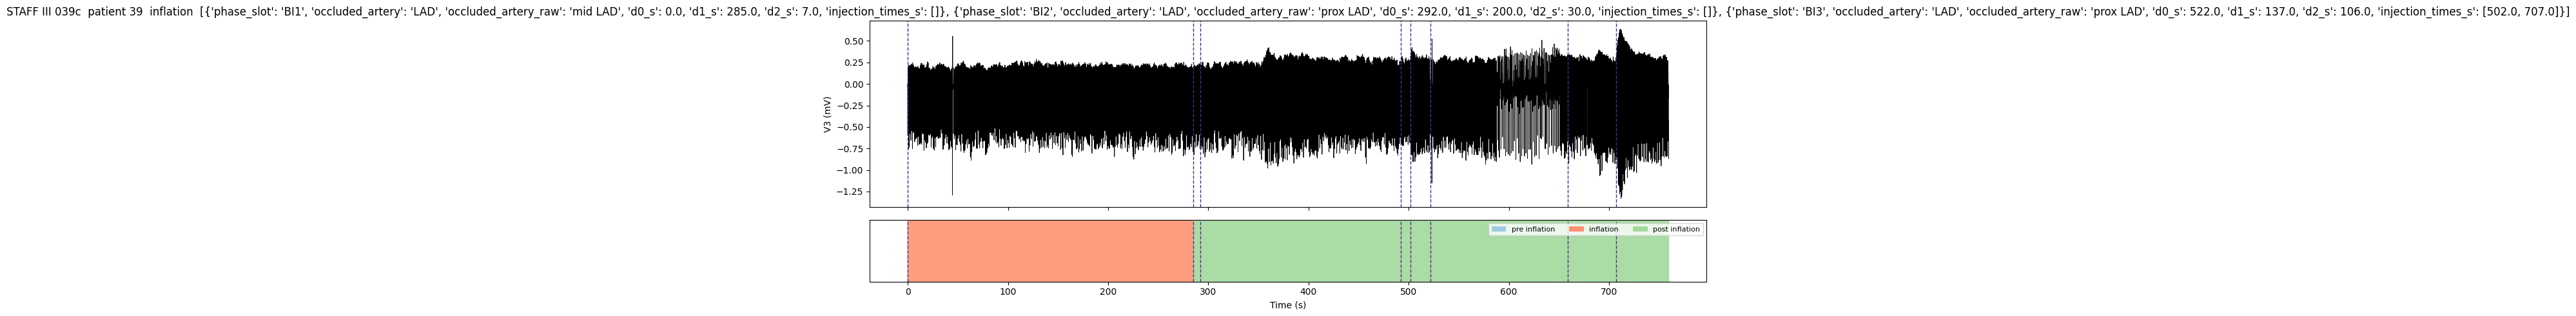

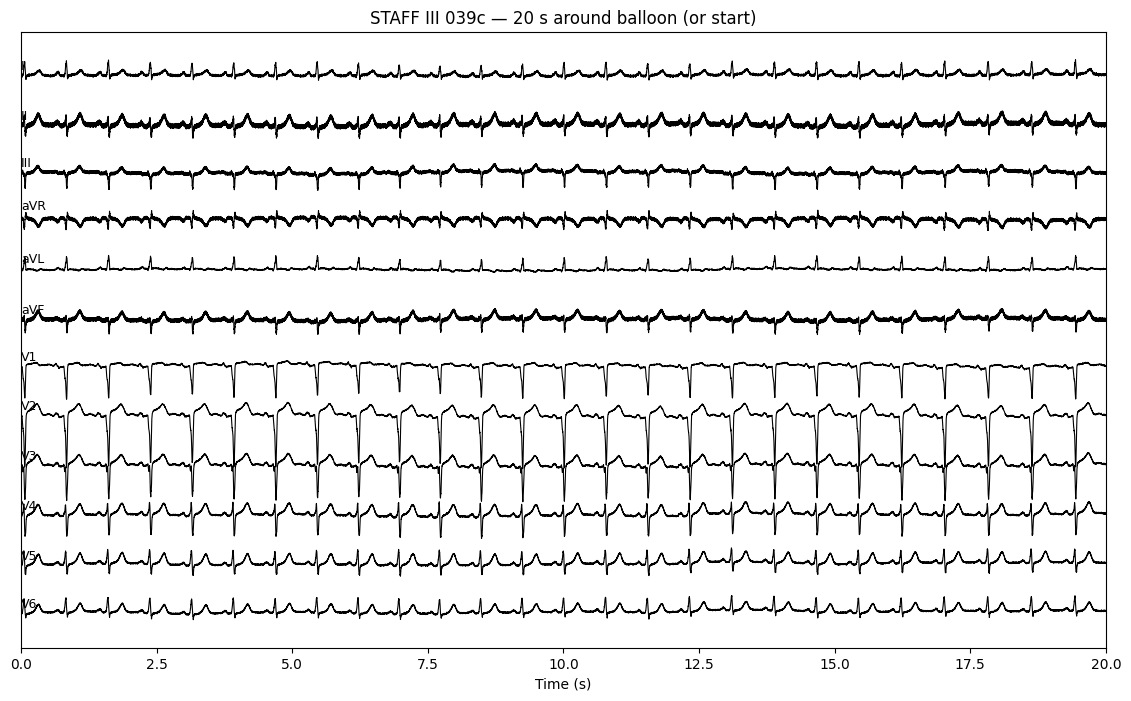

In [ ]:
import json
import pickle
from matplotlib import pyplot as plt

index = pd.read_csv(PROC_DIR / "index.csv")
infl_rows = index[index["phase"] == "inflation"]
example_id = str((infl_rows if len(infl_rows) else index).iloc[0]["record_id"])
sig = np.load(PROC_DIR / "signals" / f"{example_id}.npy")
with open(PROC_DIR / "signals" / f"{example_id}.pkl", "rb") as f:
    pickle_meta = pickle.load(f)
labels = json.loads((PROC_DIR / "labels" / f"{example_id}.json").read_text(encoding="utf-8"))

fig, axes = C.plot_staff_timeline(
    sig, pickle_meta["fs"], pickle_meta["channels"],
    labels["segments"], labels["events"],
    lead="V3",
    title=f"STAFF III {example_id}  patient {labels['patient_id']}  {labels['phase']}  {labels.get('inflations')}",
)
C.save_figure(fig, PROC_DIR, f"staff_{example_id}_timeline")
display(fig)
plt.close(fig)

# 20 s window around balloon inflation if present
onsets = [e["sample"] for e in labels["events"] if "inflation" in e["label"].lower() and "deflation" not in e["label"].lower()]
t0 = max(0.0, onsets[0] / pickle_meta["fs"] - 5) if onsets else 0.0
fig, ax = C.plot_12_lead_strip(
    sig, pickle_meta["fs"], pickle_meta["channels"],
    title=f"STAFF III {example_id} — 20 s around balloon (or start)",
    t_start=t0, t_end=t0 + 20,
)
C.save_figure(fig, PROC_DIR, f"staff_{example_id}_window")
display(fig)
plt.close(fig)

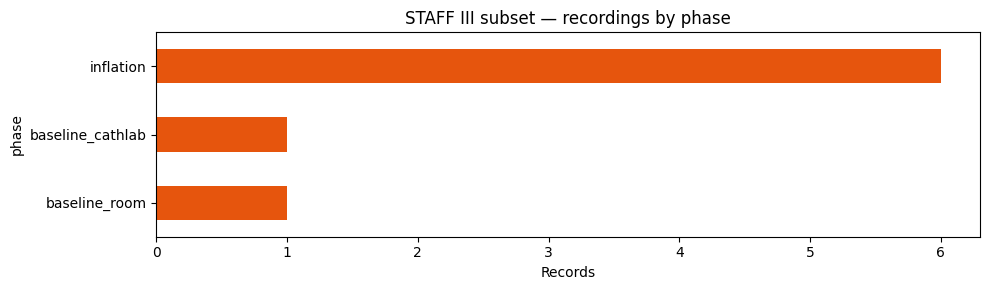

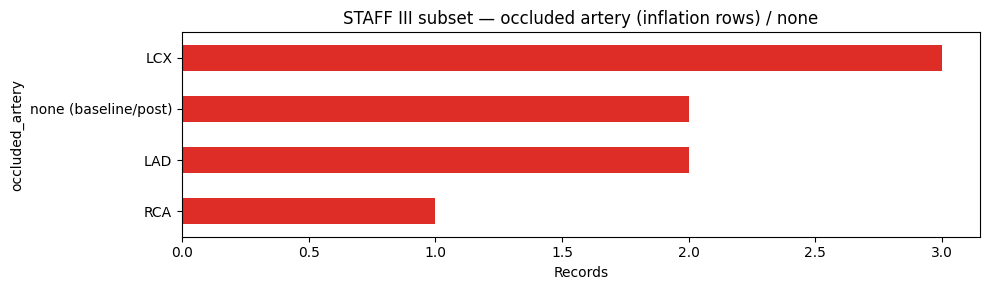

Figures → C:\Users\staso\OneDrive\Pulpit\Nauka\University\Thesis\code\ECG_Delineation\WTdelineator\data\evaluation\processed\staff_iii\figures


In [ ]:
fig, ax = C.plot_category_counts(
    index["phase"].value_counts(),
    title="STAFF III subset — recordings by phase",
    color="#e6550d",
)
C.save_figure(fig, PROC_DIR, "staff_phase_counts")
display(fig)
plt.close(fig)

artery_counts = index["occluded_artery"].fillna("none (baseline/post)").value_counts()
fig, ax = C.plot_category_counts(
    artery_counts,
    title="STAFF III subset — occluded artery (inflation rows) / none",
    color="#de2d26",
)
C.save_figure(fig, PROC_DIR, "staff_artery_counts")
display(fig)
plt.close(fig)

print("Figures →", PROC_DIR / "figures")